# Chapter 1 — Linear regression models

The executable counterpart of `docs/companion/02-ch1-regression.md`: the handbook's AR(2) for US inflation (examples 1–2) and the AR(2) with AR(1) errors (example 3), on the handbook's `inflation.xls`.

In [1]:
from pathlib import Path
import os
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from macrotoolkit import api as mtk
from macrotoolkit.run import REPO_ROOT as REPO   # never walk parent directories (HANDOFF warning)

HB = REPO / "examples" / "handbook"
HEAVY = os.environ.get("HANDBOOK_HEAVY") == "1"

def fit(name):
    """Fit an example spec (reused by hash if the run exists) and print its record."""
    run = mtk.fit(str(HB / name / "spec.yaml"))
    mc = run.mirror_check
    print(f"{name}: run {run.hash} | verdict {run.verdict} | {'; '.join(run.diagnostics['reasons'])}")
    print(f"  fit-time mirror check: max |Stan - Python| KF loglik = {mc['max_abs_diff']:.2e} over {mc['n_points']} prior draws")
    return run

def heavy(name):
    if not HEAVY:
        print(f"{name}: heavy example -- run with HANDBOOK_HEAVY=1 (a run session); skipped here.")
        return None
    return fit(name)


/root/.local/share/uv/tools/pytest/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## The AR(2) with a constant (example 1) — compare with the handbook's Table 1: α 0.2494, B₁ 1.3867, B₂ −0.4600

In [2]:
run = fit("ch1_ar2")
run.param_table().round(4)

ch1_ar2: run 3daed38410ce | verdict WARN | max R-hat 1.0228 > 1.01; min bulk/tail ESS (245/207) < 400
  fit-time mirror check: max |Stan - Python| KF loglik = 3.64e-12 over 5 prior draws


,median,ci_lo,ci_hi,rhat,ess_bulk,ess_tail
name,,,,,,
b1,1.3934,1.3063,1.4708,1.0030,342.0971,292.2710
b2,-0.4624,-0.5426,-0.3799,1.0085,350.4797,355.1763
c,0.2473,0.1185,0.3598,1.0016,345.4848,243.4140
kf_loglik,-288.7880,-292.4268,-287.7590,1.0146,245.0275,326.0052
sigma,0.7714,0.7241,0.8296,1.0228,337.2403,206.5508


The prior-predictive check: under N(0, 1) autoregressive priors a large share of prior paths is explosive — the handbook enforces stability by rejection; the toolkit shows the prior's implication.

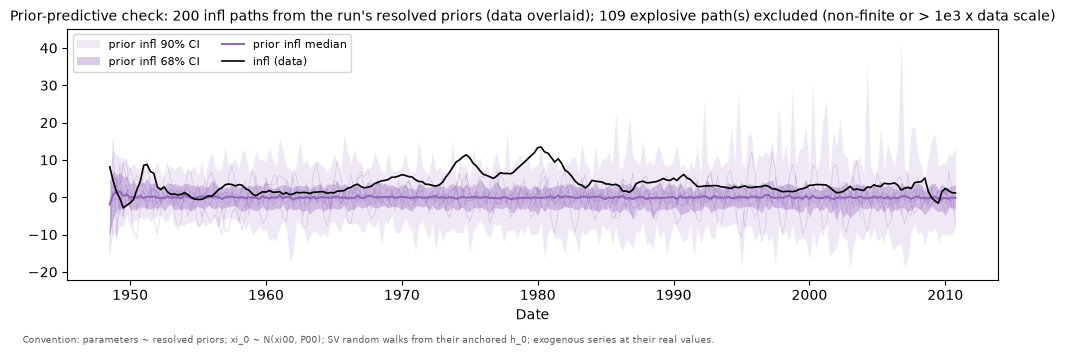

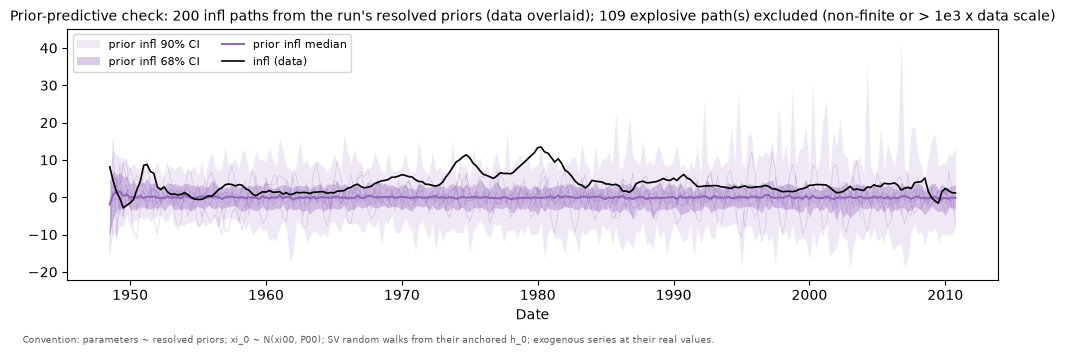

In [3]:
run.outputs().figure("prior_predictive")

## The forecast distribution (example 2): the `fan` module simulates forward from every posterior draw

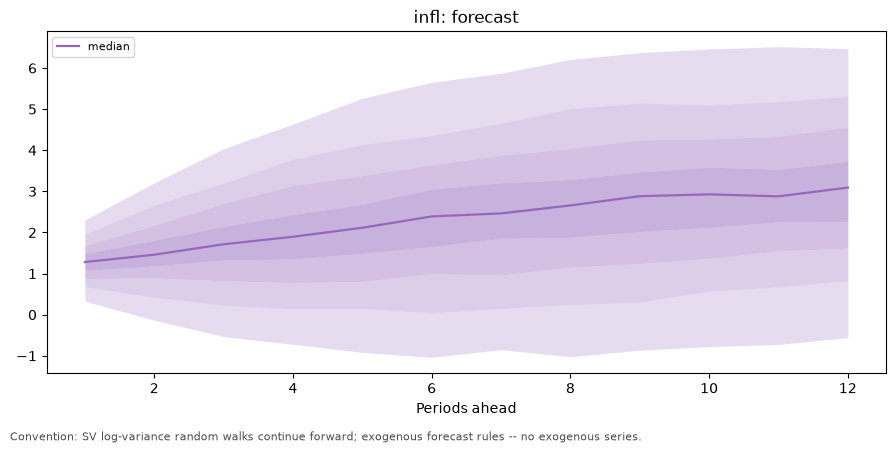

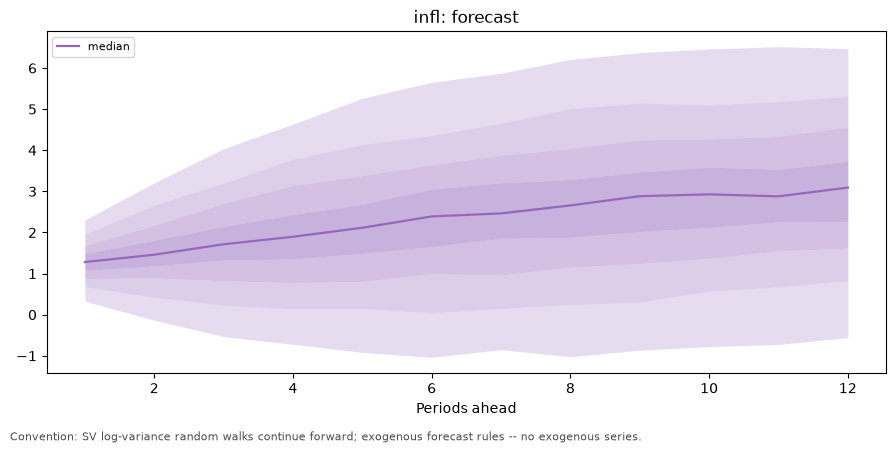

In [4]:
run.outputs().figure("fan")["infl"]

## Serially correlated errors (example 3): the exact quasi-differenced equation

The verdict at this chain length is FAIL on tail ESS — the posterior is bimodal (an autoregressive root can sit in the regression or in the error), which the handbook's Figure 14 shows as chains jumping between two configurations.

In [5]:
run = fit("ch1_ar2_ar1err")
run.param_table().round(4)

ch1_ar2_ar1err: run ecbc32188034 | verdict FAIL | max R-hat 1.0142 > 1.01; min bulk/tail ESS (146/78) < 100
  fit-time mirror check: max |Stan - Python| KF loglik = 3.64e-12 over 5 prior draws


,median,ci_lo,ci_hi,rhat,ess_bulk,ess_tail
name,,,,,,
b1,0.6162,0.4233,0.8279,1.0052,175.3907,206.8760
b2,0.0899,-0.0203,0.2024,1.0001,400.5913,300.0912
c,0.8719,0.3434,1.6003,1.0134,192.7084,116.1427
kf_loglik,-287.6085,-290.8821,-286.1308,1.0043,177.3729,88.8132
rho,0.7442,0.5506,0.8971,1.0017,146.3299,88.3006
sigma,0.7682,0.7160,0.8224,1.0084,444.3070,284.4171


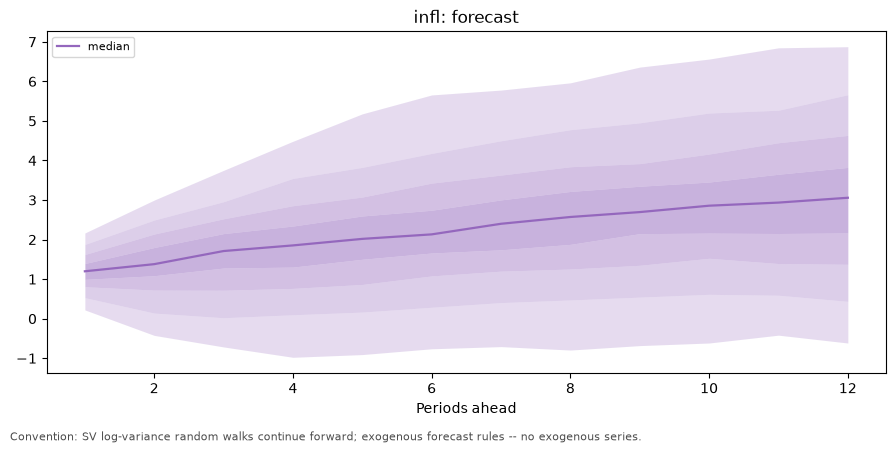

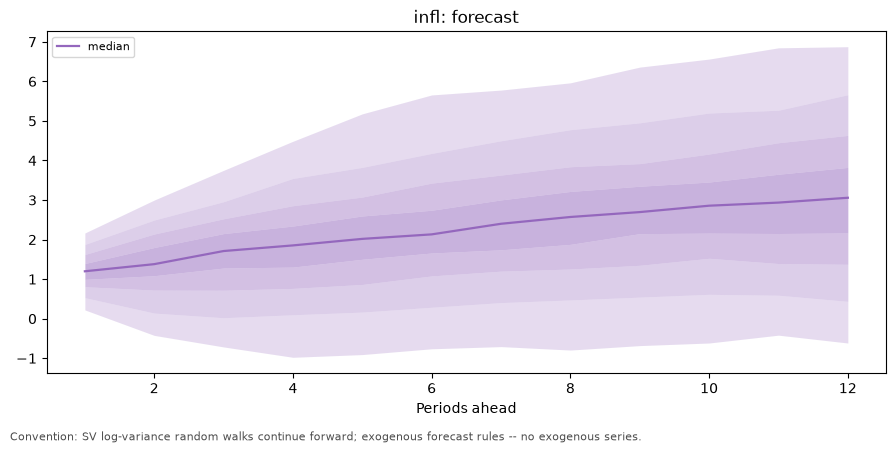

In [6]:
run.outputs().figure("fan")["infl"]

## The fast validation tier on the AR(2)

In [7]:
result = mtk.validate(HB / "ch1_ar2" / "spec.yaml", tier="fast")
for g in result.gates:
    print(f"{g.name:12s} {g.verdict}  {g.summary}")

mirror       PASS  max |Stan - Python| KF loglik = 3.725e-08 (max relative 6.788e-16) over 25 prior draws (gate max(1e-08, 1e-11 * |loglik|))
hd_identity  PASS  historical-decomposition reconstruction: max |error| = 2.13e-14 over 5 simulation-smoother draws (gate 1e-06)


In [8]:
plt.close("all")